El objetivo de este notebook es generar predicciones para la variable 'z' de redshift utilizando el resto de 

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))
from preprocess_vae import load_features

In [59]:
df = load_features()

Filtros de catálogo:
  inicial            : 29575
  maskbits==0        : 27757
  flujo>0 (griz)     : 26166
  profundidad (mag)  : 21340
  SNR>=3 (griz)      : 21287


In [60]:
df.columns

Index(['desi_id', 'mean_fiber_ra', 'mean_fiber_dec', 'z', 'zerr', 'ra', 'dec',
       'type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', 'ebv', 'brickid',
       'dchisq_psf', 'dchisq_rex', 'dchisq_exp', 'dchisq_dev', 'dchisq_ser',
       'id', 'flux_g', 'flux_r', 'flux_i', 'flux_z', 'flux_w1', 'flux_w2',
       'flux_w3', 'flux_w4', 'flux_ivar_g', 'flux_ivar_r', 'flux_ivar_i',
       'flux_ivar_z', 'flux_ivar_w1', 'flux_ivar_w2', 'flux_ivar_w3',
       'flux_ivar_w4', 'mw_transmission_i', 'fitbits', 'mw_transmission_w1',
       'brickname', 'mw_transmission_z', 'mw_transmission_g', 'maskbits',
       'mw_transmission_w2', 'mw_transmission_w3', 'objid',
       'mw_transmission_w4', 'mw_transmission_r', 'mag_g_corr', 'mag_r_corr',
       'mag_i_corr', 'mag_z_corr', 'SNR_g', 'SNR_r', 'SNR_i', 'SNR_z'],
      dtype='str')

Las features a utilizar serán las que dan información sobre la forma, tamaño y color de las galaxias, así como las coordenadas de las mismas.

In [61]:
df['mag_w1_corr'] = df['flux_w1']/df['mw_transmission_w1']
df['mag_w2_corr'] = df['flux_w2']/df['mw_transmission_w2']
df['mag_w3_corr'] = df['flux_w3']/df['mw_transmission_w3']
df['mag_w4_corr'] = df['flux_w4']/df['mw_transmission_w4']

In [62]:

df = df[['ra', 'dec', 'type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', 'flux_g', 'flux_r', 'flux_i', 'flux_z', 'flux_w1', 'flux_w2', 'flux_w3', 'flux_w4', "mag_g_corr", "mag_r_corr", "mag_i_corr", "mag_z_corr", "mag_w1_corr", "mag_w2_corr", "mag_w3_corr", "mag_w4_corr",'z']]
df.dropna(inplace=True)
X = df.drop(columns=['z'])
y = df['z']

In [63]:
y.min()

np.float64(-1.931031910083113e-05)

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Clasificación por bins de redshift
n_bins = 18
bins = np.linspace(y.min(), y.max(), n_bins + 1)
y_cls = pd.cut(y, bins=bins, include_lowest=True, labels=False)

# Split estratificado por clase de redshift
X_train, X_test, y_train, y_test, z_train, z_test = train_test_split(
    X, y_cls, y,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

numeric_features = [c for c in X.columns if c != "type"]
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ]
)

clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(
        random_state=42,
        learning_rate=0.05,
        max_depth=6,
        max_iter=300
    ))
])

clf.fit(X_train, y_train)

# Predicción de clase
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

# Reconstrucción de z_phot a partir de probabilidades de clase
class_centers = np.array([(bins[i] + bins[i + 1]) / 2 for i in range(len(bins) - 1)])
z_phot = y_proba @ class_centers

# Métricas de clasificación
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Balanced accuracy:", bacc)
print("Macro F1:", f1m)
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte:")
print(classification_report(y_test, y_pred))

# Métricas astronómicas sobre z reconstruido
delta_z = (z_phot - z_test.to_numpy()) / (1 + z_test.to_numpy())
bias = delta_z.mean()
sigma_mad = 1.4826 * np.median(np.abs(delta_z - np.median(delta_z)))
eta = (np.abs(delta_z) > 0.05).mean() * 100

print("\nMétricas sobre redshift reconstruido:")
print("<Δz> =", bias)
print("σ_MAD =", sigma_mad)
print("η [%] =", eta)

Accuracy: 0.4861437294504462
Balanced accuracy: 0.35477235026896137
Macro F1: 0.35837689902750247

Matriz de confusión:
[[ 98 101   6   1   0   0   0   0   1   3   1   1   0   1   0   0   0   0]
 [ 50 422 123   5   2   0   0   0   4   3   2   2   2   0   1   1   2   0]
 [  7 108 443  86   7   0   0   0   4   2   1   0   1   0   1   1   0   0]
 [  3  15 130 312  43  11   0   1   0   0   0   0   0   1   0   1   0   0]
 [  0   2   8 126  92  39   4   2   0   2   0   1   1   0   0   0   0   0]
 [  0   1   1  36  33 104  25   6   2   1   0   0   0   0   0   0   1   0]
 [  0   0   0   9   2  32  80  45   8   2   1   1   0   0   0   0   0   0]
 [  0   1   0   5   1  10  25 126  36  14   5   5   2   2   1   2   0   0]
 [  0   6   1   1   0   0   4  40  90  61  23   3   8   2   4   1   0   0]
 [  1   1   0   0   0   0   1   8  64  87  74  12   8   5   1   0   1   0]
 [  0   1   0   0   0   0   0   3  21  73 107  21   6   5   0   1   0   0]
 [  0   3   0   0   0   0   0   0   9  31  60  19  17  

/home/nacho/Projects/AS4501-Proyect/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nacho/Projects/AS4501-Proyect/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nacho/Projects/AS4501-Proyect/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [75]:
X.columns

Index(['ra', 'dec', 'type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic',
       'flux_g', 'flux_r', 'flux_i', 'flux_z', 'flux_w1', 'flux_w2', 'flux_w3',
       'flux_w4', 'mag_g_corr', 'mag_r_corr', 'mag_i_corr', 'mag_z_corr',
       'mag_w1_corr', 'mag_w2_corr', 'mag_w3_corr', 'mag_w4_corr'],
      dtype='str')

In [ ]:
X = X.copy()
y = df["z"].copy()

numeric_features = [c for c in X.columns if c != "type"]
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=124
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", HistGradientBoostingRegressor(
        random_state=42,
        learning_rate=0.05,
        max_depth=10,
        max_iter=300
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

MAE:  0.0807
RMSE: 0.1445
R2:   0.8661


Text(0, 0.5, 'Redshift predicho')

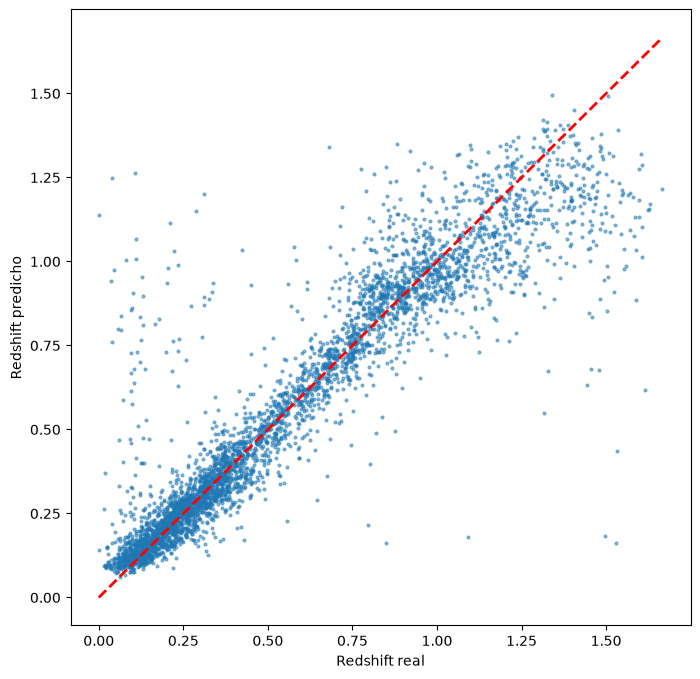

In [73]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, s=4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Redshift real")
plt.ylabel("Redshift predicho")

Feature Engineering: añadir colores

In [80]:
# Colores a partir de magnitudes corregidas
color_pairs = [
    ("g", "i"),
    ("g", "r"),
    ("r", "i"),
    ("i", "z"),
    ("z", "w1"),
    ("w1", "w2"),
    ("w2", "w3"),
    ("w3", "w4"),
]

for b1, b2 in color_pairs:
    X[f"color_{b1}{b2}"] = X[f"mag_{b1}_corr"] - X[f"mag_{b2}_corr"]


In [82]:
X

,ra,dec,type,shape_r,shape_e1,shape_e2,sersic,flux_g,flux_r,flux_i,...,mag_w3_corr,mag_w4_corr,color_gi,color_gr,color_ri,color_iz,color_zw1,color_w1w2,color_w2w3,color_w3w4
0,147.028933,-6.291716,REX,1.202857,0.000000,0.000000,1.000000,1.175249,2.545436,6.139451,...,78.409294,-2506.586850,1.709774,0.783963,0.925811,0.455596,-13.893762,14.206465,-58.731565,2584.996144
2,148.820681,-2.767036,REX,0.305442,0.000000,0.000000,1.000000,0.511285,0.731160,0.962048,...,19.844195,234.524798,0.620108,0.345543,0.274565,0.503414,22.235241,-1.327548,-18.778295,-214.680603
3,156.331327,-5.158570,SER,0.509001,-0.049165,0.140539,4.798375,10.024600,20.990934,28.348501,...,83.687996,-1398.273356,1.058748,0.757199,0.301549,0.188885,-10.723925,11.212458,-65.565355,1481.961352
5,154.755842,-1.621529,REX,0.259338,0.000000,0.000000,1.000000,0.394621,0.514861,0.843455,...,28.035550,-736.808516,0.736538,0.231755,0.504783,0.136545,21.812315,0.612276,-27.998374,764.844067
6,155.549724,-1.859350,SER,0.840928,-0.024381,0.026650,5.345087,1.871197,11.053842,20.814010,...,178.876665,-4357.935789,2.534641,1.876131,0.658509,0.340602,-44.238484,20.209348,-136.063473,4536.812454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29570,151.770339,7.574556,EXP,0.748664,0.079242,-0.310559,1.000000,0.737029,1.070557,1.249089,...,-33.086380,989.247252,0.541854,0.385317,0.156537,0.356113,21.156558,2.432220,31.369659,-1022.333632
29571,153.560079,0.738607,REX,0.830543,0.000000,0.000000,1.000000,0.805618,1.058102,1.600285,...,-77.835269,-10458.374229,0.687646,0.258793,0.428853,0.308136,19.249002,5.307935,74.903242,10380.538960
29572,158.033423,2.225414,REX,0.405263,0.000000,0.000000,1.000000,0.753930,0.985459,1.421747,...,74.195264,1033.254180,0.612828,0.241682,0.371145,0.181804,19.690311,4.207952,-76.231884,-959.058916
29573,156.590189,4.210277,SER,1.827961,-0.169518,-0.118707,0.915419,36.215622,57.453667,70.319496,...,165.980223,3588.497871,0.659384,0.461562,0.197823,0.130555,-37.225671,21.433900,-132.496632,-3422.517648


In [85]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", HistGradientBoostingRegressor(
        random_state=10,
        learning_rate=0.05,
        max_depth=6,
        max_iter=300
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

MAE:  0.0825
RMSE: 0.1486
R2:   0.8589
